In [1]:
import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time
import os

In [2]:
patch_size = 100
kernel_size = patch_size
image_size = 256
descriptor_dimension = 4

max_rotation = 360
rotation_multiple = 36
max_skew = 0

margin = 1
threshold = 0.4
learning_rate = 0.1e-2
optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
cos_sim = tf.keras.losses.CosineSimilarity()
batch_size = 256
epochs = 100000
num_filters = 4
model_path = "filters_model.h5"
backup_model_path = "backup_filters_model.h5"

In [3]:
centre_to_top_right = np.array([[1,0,-math.ceil(image_size/2)],
                                [0,1,-math.ceil(image_size/2)],
                                [0,0,1]])
top_right_to_centre = np.array([[1,0,math.ceil(image_size/2)],
                                [0,1,math.ceil(image_size/2)],
                                [0,0,1]])

patch_centre_to_top_right = np.array([[1,0,-math.ceil(patch_size/2)],
                                [0,1,-math.ceil(patch_size/2)],
                                [0,0,1]])
patch_top_right_to_centre = np.array([[1,0,math.ceil(patch_size//2)],
                                [0,1,math.ceil(patch_size//2)],
                                [0,0,1]])

def create_rotational_matrix(rotation, axis = "z"):
    rotation = np.radians(rotation)
    s = np.sin(rotation)
    c = np.cos(rotation)
    if axis == "z":
        return np.array([[c, -s, 0],
                          [s, c, 0],
                          [0, 0, 1]])
        
def create_skew_matrix(skew_x, skew_y):
     return np.array([[1, skew_x, 0],
                     [skew_y, 1, 0],
                     [0, 0, 1]])

In [4]:
def get_fixed_homography_matrix(val):
    rotation = rotation_multiple*val
    # rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), patch_centre_to_top_right))
    return homography_matrix

In [5]:
def get_random_homography_matrix():
    rotation = np.random.uniform(0,max_rotation)
    rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), patch_centre_to_top_right))
    return homography_matrix

In [6]:
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_dir_path, batch_size = 128):
        
        self.img_list = []
        for image in os.listdir(image_dir_path):
            if image == ".DS_Store":
                continue
            img = cv2.imread(os.path.join(image_dir_path, image))
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            img = img/255
            self.img_list.append(img)
            
        self.batchsize = batch_size  
                
    def __len__(self):
        return math.ceil(((image_size - patch_size)**2)/self.batchsize)
        
    def __getitem__(self, batch):
        original_images = []
        matches = []
        non_matches = []
        for _ in range(self.batchsize):
            current_image_no = np.random.randint(0, len(self.img_list))
            current_image = self.img_list[current_image_no]
            x = np.random.randint(0,image_size - patch_size)
            y = np.random.randint(0,image_size - patch_size)
            current_patch = current_image[x:x+patch_size, y:y+patch_size]
            current_patch = cv2.blur(current_patch, (3,3))
            transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            
            current_patch = np.expand_dims(current_patch, axis = -1)
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            
            original_images.append(current_patch)
            matches.append(transformed_current_patch)
            
            X = np.random.randint(0,image_size - patch_size)
            Y = np.random.randint(0,image_size - patch_size)
            random_image_no = np.random.randint(0, len(self.img_list))
            random_image = self.img_list[random_image_no]
            while(x==X & y==Y & random_image_no == current_image_no):
                X = np.random.randint(0,image_size - patch_size)
                Y = np.random.randint(0,image_size - patch_size)
                
            current_patch = random_image[X:X+patch_size, Y:Y+patch_size]
            transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            non_matches.append(transformed_current_patch)
        
            original_images = np.array(original_images)
            matches = np.array(matches)
            non_matches = np.array(non_matches)
            
            # original_images = np.array(original_images > threshold, dtype=np.double)
            # matches = np.array(matches > threshold, dtype=np.double)
            # non_matches = np.array(non_matches > threshold, dtype=np.double)
            
        return original_images, matches, non_matches

In [7]:
# class ChannelNormalization(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ChannelNormalization, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.l2_normalize(inputs, axis=-1)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ChannelNormalization, self).build(input_shape)
        
#     def get_config(self):
#         return super(ChannelNormalization, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [8]:
# class ClippingLayer(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ClippingLayer, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.clip(inputs, min_value=0.0, max_value=256.0)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ClippingLayer, self).build(input_shape)
        
#     def get_config(self):
#         return super(ClippingLayer, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [9]:
# def get_model(input_shape, descriptor_dimension):
#     inp = tf.keras.layers.Input(input_shape)
#     out = tf.keras.layers.Conv2D(descriptor_dimension, kernel_size)(inp)
#     # out = ClippingLayer()(out)
#     out = ChannelNormalization()(out)
    
#     model = tf.keras.models.Model(inputs = inp, outputs = out)
#     return model

In [10]:
# def custom_loss(original_desc, matches, non_matches):
#     original_desc = tf.squeeze(original_desc)
#     matches = tf.squeeze(matches)
#     non_matches = tf.squeeze(non_matches)
    
#     return tf.reduce_mean((1 - tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(matches, tf.transpose(non_matches))))
    

In [11]:
# model = get_model((patch_size, patch_size, 1), descriptor_dimension)
# model.summary()

In [12]:
# data_gen = CustomDataGenerator("test/img/cinema1.jpeg", batch_size)

# for epoch in range(epochs):
#     epoch_loss = 0
#     print(f"Epoch {epoch} starting...")
#     for batch in range(data_gen.__len__()):
#         all_patches, matches, non_matches = data_gen.__getitem__(batch)
#         with tf.GradientTape() as tape:
#             all_predictions = model(all_patches)
#             matches_predictions = model(matches)
#             non_matches_predictions = model(non_matches)
#             loss = custom_loss(all_predictions, matches_predictions, non_matches_predictions)
#             # print(loss)
#             epoch_loss += loss
#             gradients = tape.gradient(loss, model.trainable_variables)
#             optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        
#         # if batch%5==0:
#         #     print(loss.numpy())
#     # val_generator.on_epoch_end()
    
#     try:
#         model.save(model_path)
#         model.save(backup_model_path)
#     except Exception as e:
#         print("========= Note ================")
#         print("cant save last model")
#         print(e)
    
#     print(epoch_loss.numpy()/data_gen.__len__())
#     epoch_loss = 0

In [13]:
val_data_gen = CustomDataGenerator("test/img", 1)

In [14]:
# og, match, no_match = val_data_gen.__getitem__(0)
# fig, ax = plt.subplots(ncols=3, figsize = (11,5))
# # sns.heatmap(og[0,:,:,0], ax = ax[0], cbar = False, vmin=0, vmax=1)
# sns.heatmap(match[0,:,:,0], ax = ax[1], cbar = False, vmin=0, vmax=1)
# sns.heatmap(no_match[0,:,:,0], ax = ax[2], cbar = False, vmin=0, vmax=1)

In [15]:
filters = []
for i in range(num_filters):
    filter = tf.random.uniform(shape=(patch_size, patch_size), minval=0, maxval=1, dtype=tf.double)
    # filter = np.clip(filter, 0, 1)
    cv2.imwrite(f"filters/initial_filter{i}.jpg", np.array(filter*255))
    filter = tf.Variable(tf.convert_to_tensor(filter))
    filters.append(filter)

In [16]:
def inverse_sigmoid(x):
    epsilon = 1e-7  # to avoid division by zero and log of zero
    y = tf.clip_by_value(x, epsilon, 1 - epsilon)
    return tf.math.log(y / (1 - y))

In [17]:
def get_gaussian_kernel(shape=(3,3), sigma=0.5):
    """build the gaussain filter"""
    m,n = [(ss-1.)/2. for ss in shape]
    x = tf.expand_dims(tf.range(-n,n+1,dtype=tf.float32),1)
    y = tf.expand_dims(tf.range(-m,m+1,dtype=tf.float32),0)
    h = tf.exp(tf.math.divide_no_nan(-((x*x) + (y*y)), 2*sigma*sigma))
    h = tf.math.divide_no_nan(h,tf.reduce_sum(h))
    h =tf.cast(h,dtype=tf.double)
    return h

def gaussian_blur(inp, shape=(3,3), sigma=0.5):
    """Convolve using tf.nn.depthwise_conv2d"""
    org_shape =tf.shape(inp)
    inp = tf.reshape(inp,( 1,*org_shape,1))
    in_channel = tf.shape(inp)[-1]
    k = get_gaussian_kernel(shape,sigma)
    k = tf.expand_dims(k,axis=-1)
    k = tf.repeat(k,in_channel,axis=-1)
    k = tf.reshape(k, (*shape, in_channel, 1))
    # using padding same to preserve size (H,W) of the input
    conv = tf.nn.depthwise_conv2d(inp, k, strides=[1,1,1,1],padding="SAME")
    conv = tf.reshape(conv,org_shape)
    return conv

def arrange_filter(filter):
    mx = np.max(filter)
    mn = np.min(filter)
    filter = filter - mn
    filter = (filter/mx)*255
    return filter

In [18]:
def custom_loss(desc1_og_img, desc1_trans_img, desc1_rand_img, filters):
    
    # desc1_og_img_sum = tf.reduce_sum(desc1_og_img)
    # desc1_trans_img_sum = tf.reduce_sum(desc1_trans_img)
    # desc1_rand_img_sum = tf.reduce_sum(desc1_rand_img)
    # print(desc1_og_img_sum)
    # print(desc1_trans_img_sum)
    # print(desc1_rand_img_sum)
    descriptor_loss = tf.maximum(0, tf.reduce_sum(abs(desc1_og_img - desc1_trans_img)) - tf.reduce_sum(abs(desc1_rand_img - desc1_og_img)) + margin)
    filter_loss=0
    # for i in range(int(360/rotation_multiple)):
    # h_m = get_random_homography_matrix()
    # changed_sigmoid_filter = cv2.warpPerspective(sigmoid_filter.numpy(), h_m, (patch_size, patch_size))
    # filter_loss = filter_loss+1 - -cos_sim(tf.reshape(changed_sigmoid_filter, [-1]), tf.reshape(sigmoid_filter, [-1]))
    
#     loss = (descriptor_loss + (0.5*filter_loss))/5
    filter_numbers = np.random.choice(np.arange(0, len(filters)), size=2, replace=False)
    filter1 = tf.keras.activations.tanh(filters[filter_numbers[0]])
    filter2 = tf.keras.activations.tanh(filters[filter_numbers[1]])

    filter_loss = -cos_sim(filter1, filter2) + 1
    
    loss = (descriptor_loss+ filter_loss/6 )/3.4
    
    print(f"""
          descriptor loss: {descriptor_loss}
          filter loss: {filter_loss}
          loss: {loss}""")
    return loss

In [22]:
for i in range(epochs):
    og, match, no_match = val_data_gen.__getitem__(0)
    with tf.GradientTape() as tape:     
        og = tf.reshape(og, [-1])
        match = tf.reshape(match, [-1])
        no_match = tf.reshape(no_match, [-1])
        desc1_og_img = [] #tf.Variable(tf.random.uniform(shape=[4], minval=0, maxval=1, dtype=tf.float32))
        desc1_trans_img = [] #tf.Variable(tf.random.uniform(shape=[4], minval=0, maxval=1, dtype=tf.float32))
        desc1_rand_img = [] #tf.Variable(tf.random.uniform(shape=[4], minval=0, maxval=1, dtype=tf.float32))
        
        for filter_number, filter in enumerate(filters):
        # desc1_og_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(og[0,:,:,0], filter))
        # desc1_trans_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(match[0,:,:,0], filter))
        # desc1_rand_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(no_match[0,:,:,0], filter))
        
            sigmoid_filter = tf.keras.activations.tanh(filter)
            sigmoid_filter_1d = tf.reshape(sigmoid_filter, [-1])
        
        # desc1_og_img = tf.math.l2_normalize(og[0,:,:,0] @ sigmoid_filter)
        # desc1_trans_img = tf.math.l2_normalize(match[0,:,:,0] @ sigmoid_filter)
        # desc1_rand_img = tf.math.l2_normalize(no_match[0,:,:,0] @ sigmoid_filter)
        
            desc1_og_img.append(-cos_sim(og, sigmoid_filter_1d))
            # print(desc1_og_img)
            desc1_trans_img.append(-cos_sim(sigmoid_filter_1d, match))
            desc1_rand_img.append(-cos_sim(sigmoid_filter_1d, no_match))
        
        desc1_og_img = tf.convert_to_tensor(desc1_og_img)
        desc1_trans_img = tf.convert_to_tensor(desc1_trans_img)
        desc1_rand_img = tf.convert_to_tensor(desc1_rand_img)
        
        loss = custom_loss(desc1_og_img, desc1_trans_img, desc1_rand_img, filters)
        gradients = tape.gradient(loss, filters)
        optimizer.apply_gradients(zip(gradients, filters))
       
    if i%500 == 0:
        # sns.heatmap(filter,cbar=False)
        for filter_number, filter in enumerate(filters):
            filter.assign_add(tf.random.uniform(shape=(patch_size, patch_size), minval=loss.numpy()*-0.6, maxval=loss.numpy()*0.6, dtype=tf.double))
            t = time.time()
            cv2.imwrite(f"filters/filter_{int(t)}_{filter_number}.jpg", np.array(arrange_filter(filter)))
            # plt.savefig(f"filters/filter1_{int(t)}.jpg")
            # filter = tf.Variable(tf.keras.activations.sigmoid(filter))
            # optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
            
            # filter.assign(gaussian_blur(filter))
        # print(loss.numpy())
    if i%1000 == 0 and i != 0:
        for filter_number, filter in enumerate(filters):
            filter.assign(gaussian_blur(filter))
        


          descriptor loss: 0.9407795071601868
          filter loss: 1.2858588695526123
          loss: 0.33973217010498047

          descriptor loss: 0.803222119808197
          filter loss: 1.294060468673706
          loss: 0.2996761202812195

          descriptor loss: 0.9007571935653687
          filter loss: 1.4353070259094238
          loss: 0.3352867662906647

          descriptor loss: 0.25904136896133423
          filter loss: 1.3862769603729248
          loss: 0.14414338767528534

          descriptor loss: 0.7796325087547302
          filter loss: 1.3860130310058594
          loss: 0.29724547266960144

          descriptor loss: 0.912517786026001
          filter loss: 1.2934880256652832
          loss: 0.3317938446998596

          descriptor loss: 0.46606600284576416
          filter loss: 1.4355626106262207
          loss: 0.20744894444942474

          descriptor loss: 0.8133617639541626
          filter loss: 1.3247227668762207
          loss: 0.3041614294052124

    

KeyboardInterrupt: 

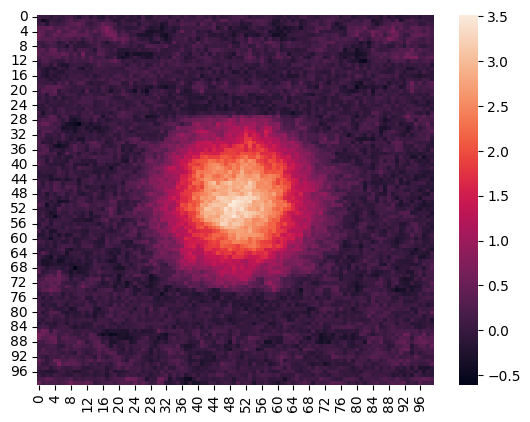

In [20]:
sns.heatmap(filters[0])
t = time.time()
plt.savefig(f"filters/filter1_{int(t)}.jpg")

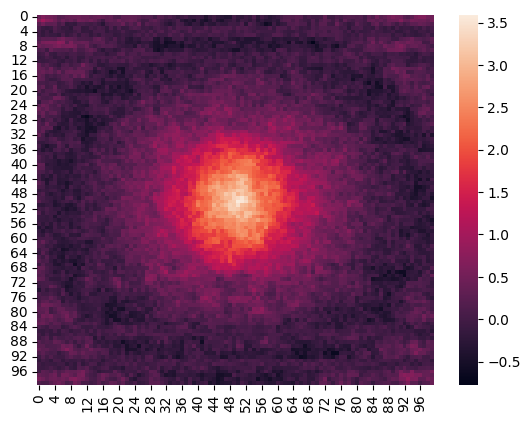

In [21]:

sns.heatmap(filters[2])
t = time.time()
plt.savefig(f"filters/filter1_{int(t)}.jpg")